# Phase 4: Descriptive Analysis and Visualizations

<div dir='ltr' class='alert alert-info'>
    In this notebook, we perform an Exploratory Data Analysis (EDA) on the cleaned Iranian cinema dataset. Our goal is to understand the trends of the industry, such as production volume over time, dominant genres, and the most active individuals.
</div>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

<div dit='ltr' class='alert alert-warning'>
Step 1: Historical Production Trend
First we visualize the volume of cinematic productions over the years.
</div>

<Axes: title={'center': 'Iran cinema production trend'}, xlabel='startYear'>

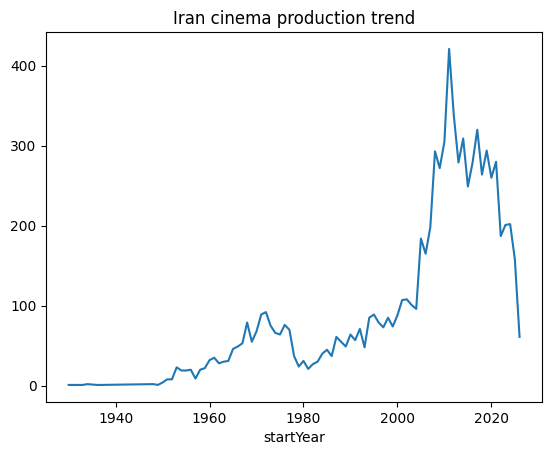

In [3]:
df = pd.read_parquet('../data/processed/iran_cinema_clean.parquet')

df_films_per_year = df.drop_duplicates('tconst').groupby('startYear').size()
df_films_per_year.plot(kind='line', title='Iran cinema production trend')

<div class='alert alert-warning'>
Step 2: Most Active Individuals

find the most prolific figures in Iranian cinema
</div>

In [19]:
top_people = df.groupby(['nconst', 'primaryName']).size().sort_values(ascending=False).head(20)
print(top_people)

nconst     primaryName          
nm0451571  Hamideh Kheirabadi       168
nm2465620  Mehdi Aminikhah          148
nm1714957  Kianoosh Gerami          136
nm1028434  Reza Beyk Imanverdi      129
nm2932763  Siamak Ash'arioon        128
nm1286513  Kazem Afrandnia          126
nm5747379  Heshmatollah Aramideh    123
nm0556305  Jamshid Mashayekhi       116
nm0707308  Mehran Rajabi            115
nm0539339  Naser Malek Motiee       111
nm0994308  Iraj Ghaderi             110
nm2114785  Behnoosh Bakhtiari       109
nm5250420  Hasan Asadi              109
nm0049076  Enayat Bakhshi           109
nm0008206  Akbar Abdi               109
nm1184348  Dariush Asadzade         109
nm1824944  Ali Miri                 106
nm1164771  Ahmad Ghadakchian        105
nm2182713  Saideh Arab              105
nm2746789  Mir Taher Mazloomi       102
dtype: int64


<div class='alert alert-warning'>
Step 3: Genre Distribution
Since a single title can have multiple genres separated by commas, we need to split and "explode" the 'genres' column. This allows us to accurately count and visualize the absolute frequency of each genre.
</div>

<Axes: title={'center': 'repetetive genres'}, xlabel='genres'>

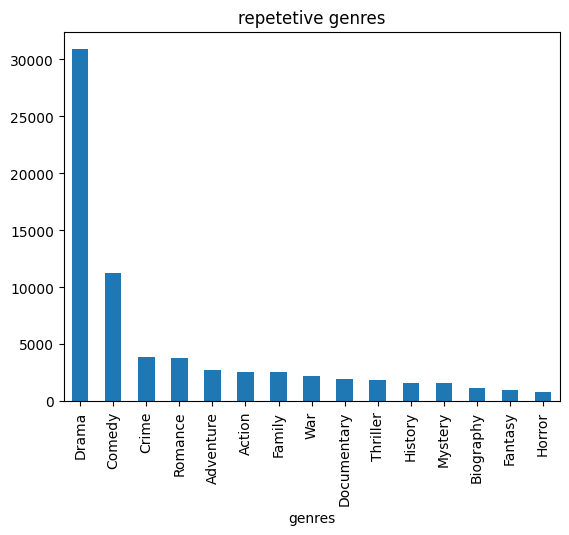

In [20]:
genre_counts = df['genres'].dropna().str.split(',').explode().value_counts()
genre_counts.head(15).plot(kind='bar', title='repetetive genres')

<div class='alert alert-warning'>
Step 4: Integrating IMDb Ratings
To evaluate the ratings of these titles, we load the 'title.ratings' dataset and merge it with our cleaned dataframe using a left join.
</div>

In [5]:
df_ratings = pd.read_csv('../data/raw/title.ratings.tsv.gz', sep='\t')

In [6]:
df_films_rated = df.merge(df_ratings, on='tconst', how='left')

In [7]:
df_films_rated.head()

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres,ordering,nconst,category,primaryName,averageRating,numVotes
0,tt0044728,movie,Huracán Ramírez,Huracán Ramírez,0,1953,None,103.0,"Action,Comedy,Crime",1,nm0798270,actor,David Silva,6.9,49.0
1,tt0044728,movie,Huracán Ramírez,Huracán Ramírez,0,1953,None,103.0,"Action,Comedy,Crime",2,nm0739131,actress,Titina Romay,6.9,49.0
2,tt0044728,movie,Huracán Ramírez,Huracán Ramírez,0,1953,None,103.0,"Action,Comedy,Crime",3,nm0327643,actress,Carmelita González,6.9,49.0
3,tt0044728,movie,Huracán Ramírez,Huracán Ramírez,0,1953,None,103.0,"Action,Comedy,Crime",4,nm0273508,actor,Freddy Fernández,6.9,49.0
4,tt0044728,movie,Huracán Ramírez,Huracán Ramírez,0,1953,None,103.0,"Action,Comedy,Crime",5,nm0414109,actor,Tonina Jackson,6.9,49.0


<div class='alert alert-warning'>
Step 4.1: Rating Coverage Check
Let's verify the percentage of our Iranian films that actually have a registered IMDb rating.
</div>

In [23]:
print(df_films_rated['averageRating'].notna().mean())

0.5809184128399465


<div class='alert alert-warning'>
Step 4.2: Setting a Reliability Threshold
IMDb ratings based on a very small number of votes can be heavily skewed and statistically unreliable. We will apply a minimum threshold  to filter out untrustworthy ratings.
</div>

In [24]:
print(df_films_rated['numVotes'].describe())

count    42999.000000
mean       160.783855
std        493.002834
min          5.000000
25%         16.000000
50%         32.000000
75%        108.000000
max       7746.000000
Name: numVotes, dtype: float64


In [25]:
df_reliable = df_films_rated[df_films_rated['numVotes'] >= 50]

In [26]:
print(df_films_rated.shape)

(74019, 15)


<div class='alert alert-warning'>
Step 5: Production Volume vs. Average Rating
Exploratory Question: Did the significant surge in production volume (especially post-2000) have any correlation with the average quality (IMDb rating) of the movies? 
</div>

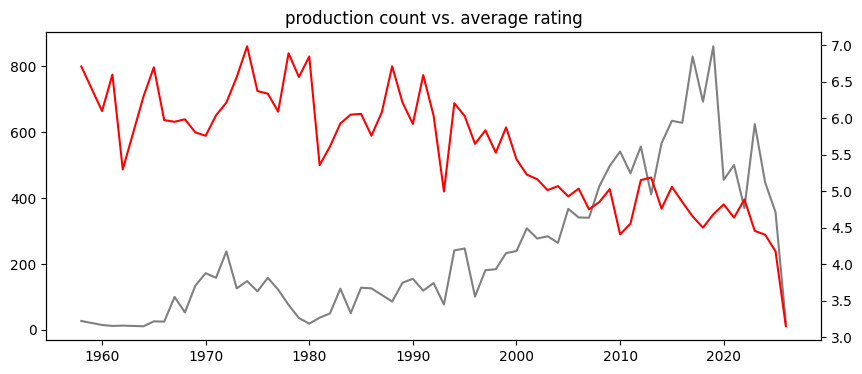

In [31]:
yearly_stats = df_reliable.groupby('startYear').agg(
    film_count=('tconst', 'count'),
    avg_rating=('averageRating', 'mean')
)

fig, ax1 = plt.subplots(figsize=(10,4))
ax1.plot(yearly_stats.index, yearly_stats['film_count'], color='gray')
ax2 = ax1.twinx()
ax2.plot(yearly_stats.index, yearly_stats['avg_rating'], color='red')
plt.title('production count vs. average rating')
plt.show()